In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Wczytanie danych

In [8]:
df = pd.read_csv("/home/zofia/Desktop/Projekt_mldd/explainable-fingerprints/data/DRD2/ifp.csv")
print(df.shape)
df.head()

(1583, 118)


,molecule_name,label,TYR37.A_Hydrophobic,VAL91.A_HBDonor,VAL91.A_Hydrophobic,VAL91.A_VdWContact,VAL91.A_XBDonor,LEU94.A_HBDonor,LEU94.A_Hydrophobic,LEU94.A_VdWContact,...,TRP413.A_HBAcceptor,TRP413.A_Hydrophobic,TRP413.A_PiStacking,TRP413.A_VdWContact,TRP413.A_XBDonor,TYR416.A_HBDonor,TYR416.A_Hydrophobic,TYR416.A_PiStacking,TYR416.A_VdWContact,TYR416.A_XBDonor
0,CHEMBL83617,1,0,0,0,1,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
1,CHEMBL3102875,1,0,0,0,1,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
2,CHEMBL4750660,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,CHEMBL4751063,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
4,CHEMBL3423332,1,0,0,0,0,0,0,1,1,...,0,1,0,1,0,0,0,0,0,0


In [9]:
df['label'].value_counts()

label
0    798
1    785
Name: count, dtype: int64

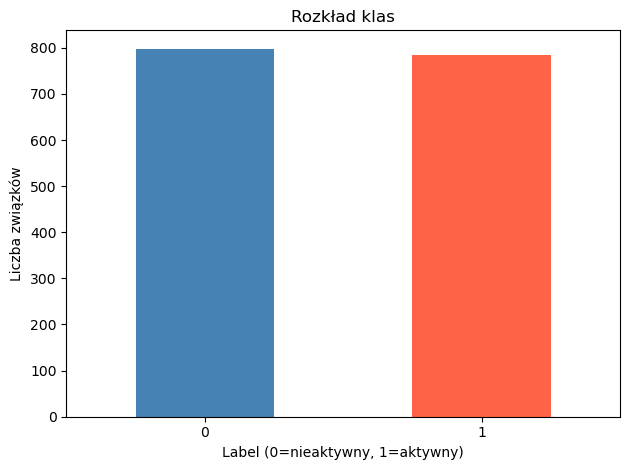

In [12]:
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Rozkład klas')
plt.xlabel('Label (0=nieaktywny, 1=aktywny)')
plt.ylabel('Liczba związków')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
X = df.drop(columns=['molecule_name', 'label'])
y = df['label']

feature_names = X.columns.tolist()

print(f'Liczba cech: {X.shape[1]}')
print(f'Liczba związków: {X.shape[0]}')

Liczba cech: 116
Liczba związków: 1583


In [31]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Podział na test i trening

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Zbiór treningowy:{X_train.shape[0]}')
print(f'Zbiór testowy:{X_test.shape[0]}')

Zbiór treningowy:1266
Zbiór testowy:317


In [33]:
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

In [34]:
xgb.fit(X_train, y_train)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
print(f"AUC: {roc_auc_score(y_test, y_prob_xgb):.3f}")

/home/zofia/Desktop/Projekt_mldd/explainable-fingerprints/.pixi/envs/default/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [23:49:22] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125046773/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.692


## 3. Optymalizacja modeli

In [ ]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':  ['sqrt', 'log2', 0.3]
}

In [ ]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    n_iter=30,          
    cv=5,                
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/zofia/Desktop/Projekt_mldd/explainable-fingerprints/.pixi/envs/default/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/zofia/Desktop/Projekt_mldd/explainable-fingerprints/.pixi/envs/default/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/zofia/Desktop/Projekt_mldd/explainable-fingerprints/.pixi/envs/default/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

In [44]:
print(f"Najlepsze parametry: {rf_search.best_params_}")
print(f"Najlepszy AUC: {rf_search.best_score_:.3f}")

best_rf = rf_search.best_estimator_
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]
print(f"AUC na zbiorze testowym: {roc_auc_score(y_test, y_prob_best_rf):.3f}")

Najlepsze parametry: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Najlepszy AUC: 0.755
AUC na zbiorze testowym: 0.722


In [ ]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5]
}

In [39]:
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    xgb_params,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/zofia/Desktop/Projekt_mldd/explainable-fingerprints/.pixi/envs/default/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [23:51:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125046773/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/zofia/Desktop/Projekt_mldd/explainable-fingerprints/.pixi/envs/default/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [23:51:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125046773/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/zofia/Desktop/Projekt_mldd/explainable-fingerprints/.pixi/envs/default/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [23:51:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125046773/work/src/learner.cc:782: 
Parameters: { "use_label_en

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [40]:
print(f"Najlepsze parametry: {xgb_search.best_params_}")
print(f"Najlepszy AUC: {xgb_search.best_score_:.3f}")

best_xgb = xgb_search.best_estimator_
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]
print(f"AUC na zbiorze testowym: {roc_auc_score(y_test, y_prob_best_xgb):.3f}")

Najlepsze parametry: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
Najlepszy AUC: 0.734
AUC na zbiorze testowym: 0.673


In [41]:
finalne = {
    'RF (bazowy)': roc_auc_score(y_test, wyniki['Random Forest']['y_prob']),
    'RF (optimized)': roc_auc_score(y_test, y_prob_best_rf),
    'XGBoost (bazowy)': roc_auc_score(y_test, y_prob_xgb),
    'XGBoost (optim.)': roc_auc_score(y_test, y_prob_best_xgb),
}
for nazwa, auc in sorted(finalne.items(), key=lambda x: -x[1]):
    print(f"  {nazwa:<22} AUC = {auc:.3f}")

  RF (bazowy)            AUC = 0.722
  RF (optimized)         AUC = 0.722
  XGBoost (bazowy)       AUC = 0.692
  XGBoost (optim.)       AUC = 0.673


In [46]:
import shap

shap.initjs()

/home/zofia/Desktop/Projekt_mldd/explainable-fingerprints/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Finalny model

In [47]:
final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Nieaktywny', 'Aktywny']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}')

              precision    recall  f1-score   support

  Nieaktywny       0.69      0.67      0.68       160
     Aktywny       0.67      0.69      0.68       157

    accuracy                           0.68       317
   macro avg       0.68      0.68      0.68       317
weighted avg       0.68      0.68      0.68       317

AUC-ROC: 0.722


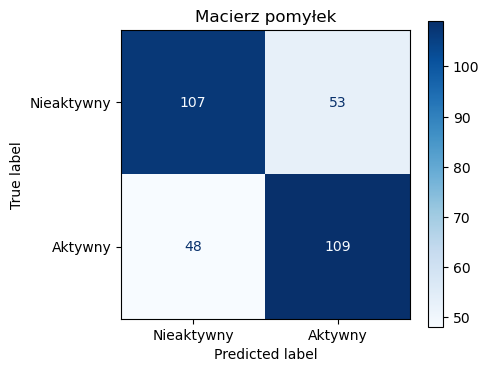

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    final_model, X_test, y_test,
    display_labels=['Nieaktywny', 'Aktywny'],
    cmap='Blues', ax=ax
)
ax.set_title('Macierz pomyłek')
plt.tight_layout()
plt.show()

## 5. SHAP
explanation.values ma 317 związków 116 cech i 2 klasy, biore klasę 1 bo ma aktywne związki
SHAP - o ile predykcja dla tefo związku zmieniłaby się gdybyśmy usuneli to oddziaływanie

In [53]:
explainer = shap.TreeExplainer(final_model)
explanation = explainer(X_test)  
sv = explanation.values[:, :, 1] 
print(f'SHAP values shape: {sv.shape}')
print(f'X_test shape: {X_test.shape}')

SHAP values shape: (317, 116)
X_test shape: (317, 116)


## 6. Summary plot
kazda kropka to jeden związek, pozycja na osi X to wartość SHAP, kolor - czy to oddziaływanie wtym związku wynosi 0 (niebieski), czy 1 (czerwony)

ASP114.A_Cationic - najważniejsza cecha w modelu, gdy ligand tworzy oddziaływanie kationowe z asparaginianem w pozycji 114, model bardzo pewnie klasyfikuje go jako aktywny

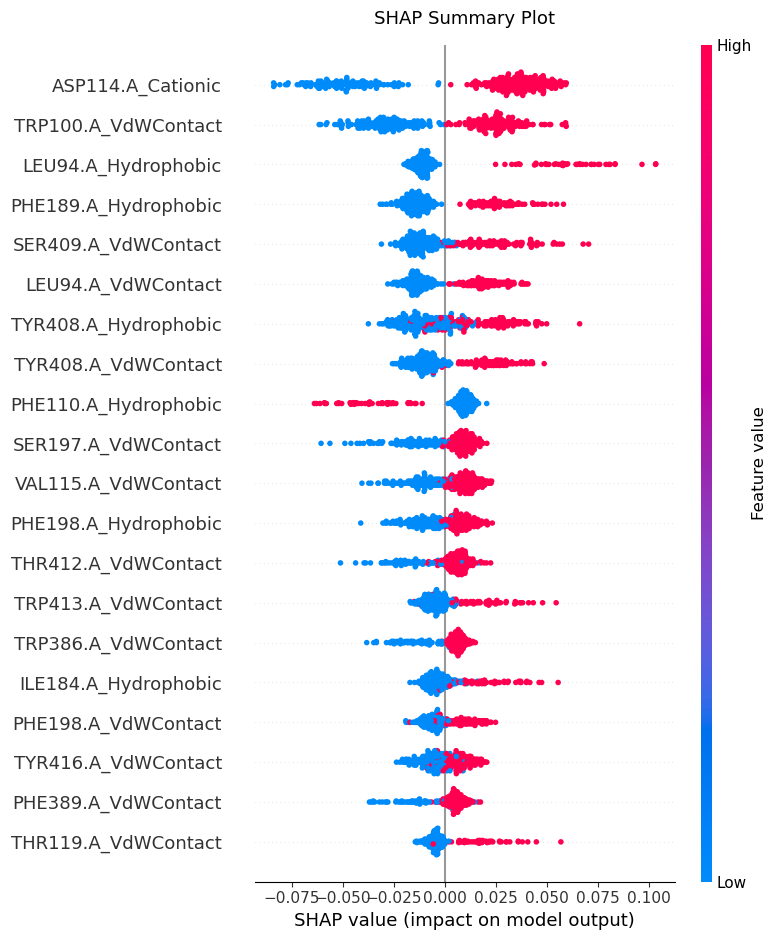

In [54]:
shap.summary_plot(
    sv, X_test,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

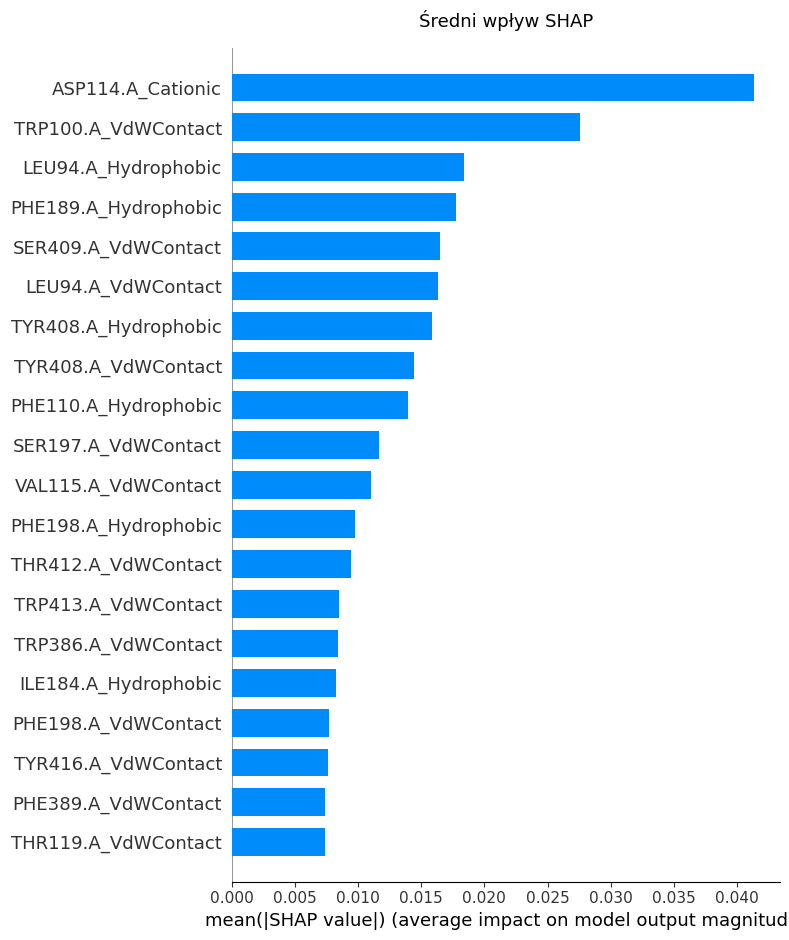

In [55]:
shap.summary_plot(
    sv, X_test,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Średni wpływ SHAP', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

## 7. Agregacja per aminokwas
Tutaj który aminokwas jest kluczowy, a nie który typ

In [ ]:
mean_shap = np.abs(sv).mean(axis=0)

shap_df = pd.DataFrame({
    'feature': feature_names,
    'mean_shap': mean_shap
}).sort_values('mean_shap', ascending=False)

shap_df['aminokwas'] = shap_df['feature'].apply(lambda x: x.rsplit('_', 1)[0])
shap_df['typ_oddzialywania'] = shap_df['feature'].apply(lambda x: x.rsplit('_', 1)[1])

aa_shap = (
    shap_df.groupby('aminokwas')['mean_shap']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_shap': 'shap_total'})
)
aa_shap['ranking_shap'] = range(1, len(aa_shap) + 1)

print(aa_shap.head(15).to_string(index=False))

aminokwas  shap_total  ranking_shap
 ASP114.A    0.047572             1
 TRP100.A    0.036170             2
  LEU94.A    0.034713             3
 TYR408.A    0.033888             4
 PHE189.A    0.024542             5
 SER409.A    0.020565             6
 TRP413.A    0.018119             7
 PHE198.A    0.017409             8
 PHE110.A    0.016294             9
 SER197.A    0.015840            10
 TYR416.A    0.015680            11
 VAL115.A    0.015382            12
 PHE389.A    0.015357            13
 ILE184.A    0.014472            14
 TRP386.A    0.013453            15


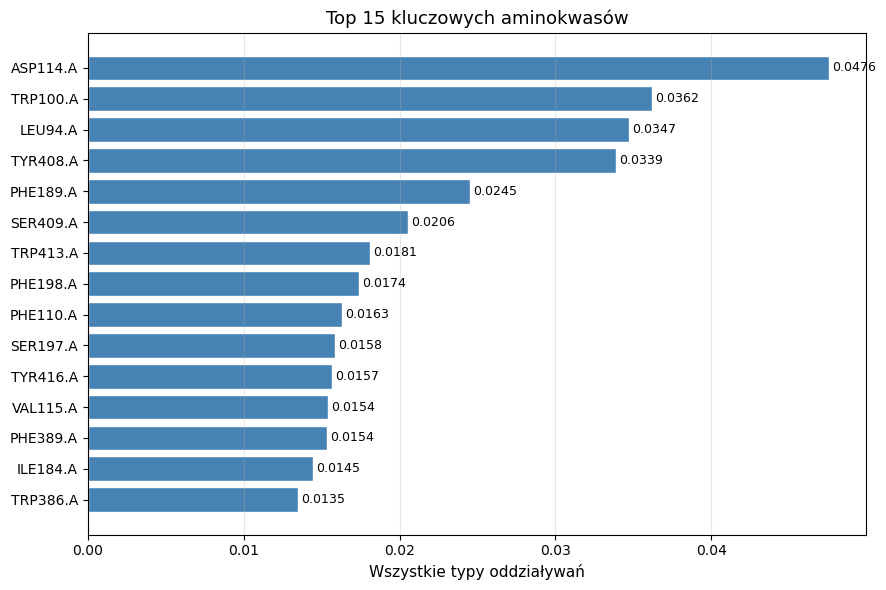

In [65]:
top15_aa = aa_shap.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    top15_aa['aminokwas'][::-1],
    top15_aa['shap_total'][::-1],
    color='steelblue', edgecolor='white'
)
ax.set_xlabel('Wszystkie typy oddziaływań', fontsize=11)
ax.set_title('Top 15 kluczowych aminokwasów', fontsize=13)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top15_aa['shap_total'][::-1]):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Typy oddziaływań dla top 5 aa
dla każdego kluczowego aminokwasu jakie sa dominujace oddzialywania

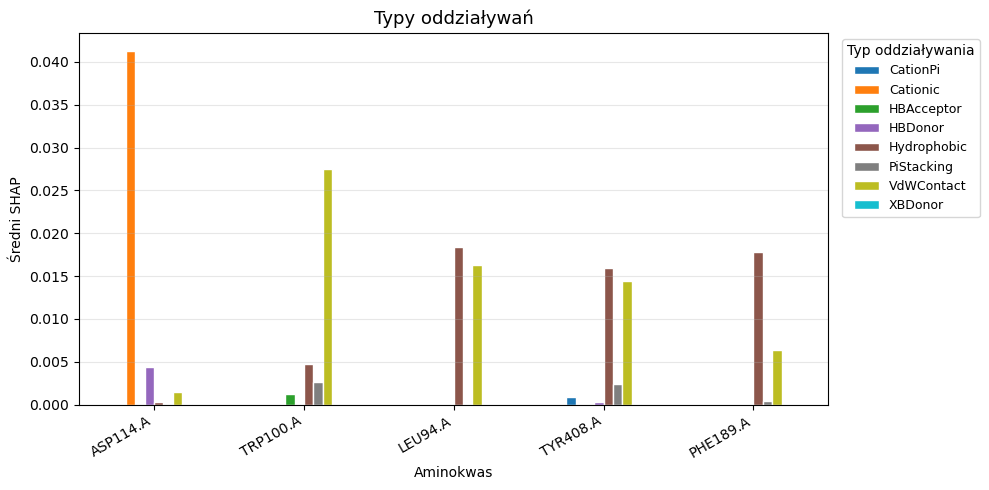

In [60]:
top5_aminokwasy = aa_shap.head(5)['aminokwas'].tolist()

top5_df = shap_df[shap_df['aminokwas'].isin(top5_aminokwasy)].copy()

fig, ax = plt.subplots(figsize=(10, 5))
pivot = top5_df.pivot_table(
    index='aminokwas', columns='typ_oddzialywania',
    values='mean_shap', fill_value=0
)
pivot.loc[top5_aminokwasy].plot(
    kind='bar', ax=ax, colormap='tab10', edgecolor='white'
)
ax.set_title('Typy oddziaływań', fontsize=13)
ax.set_xlabel('Aminokwas')
ax.set_ylabel('Średni SHAP')
ax.legend(title='Typ oddziaływania', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()